In [1]:
# Copyright (c) Sebastian Raschka under Apache License 2.0 (see LICENSE.txt).
# Source for "Build a Large Language Model From Scratch"
#   - https://www.manning.com/books/build-a-large-language-model-from-scratch
# Code: https://github.com/rasbt/LLMs-from-scratch

import matplotlib.pyplot as plt
import os
import requests
import torch
import tiktoken

from previous_chapters import GPTModel, create_dataloader_v1, generate_text_simple


In [2]:
### 중요: lOSS를 계산합니다.
def calc_loss_batch(input_batch, target_batch, model, device):
    """
    하나의 배치(Batch)에 대해 모델의 예측값과 실제값 사이의 오차(Loss)를 계산합니다.
    """
    input_batch, target_batch = ???????, ???????
    
    logits = ???????
    
    loss = ???????

    return loss


In [3]:
### 중요: 모델을 학습합니다.
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    """
    [핵심] 모델 훈련을 담당하는 메인 루프입니다.
    """
    # 로그 저장을 위한 리스트들
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen = 0
    global_step = -1

    # Epoch: 전체 데이터셋을 한 번 훑는 단위
    for epoch in range(num_epochs):
        model.???????()
        
        for ???????, ??????? in ???????:

            # region [기울기 초기화]
            ???????
            
            # region [손실 계산]
            loss = ???????

            # region [역전파 수행]
            ??????????????

            # [Step 4] 가중치 업데이트: 계산된 기울기를 이용해 파라미터 수정
            ???????
            
            tokens_seen += input_batch.numel() # 처리한 토큰 수 카운트
            global_step += 1

            # 일정 스텝마다 검증(Evaluation) 수행 및 로그 출력
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 한 에포크가 끝날 때마다 샘플 문장을 생성하여 모델이 똑똑해지고 있는지 확인
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [4]:
### 중요: 결과를 생성합니다. validation 체크
def generate(model, idx, max_new_tokens, context_size, eos_id=None):
    """
    고급 텍스트 생성 함수입니다. (Top-k 샘플링 & Temperature Scaling 포함)
    
    Args:
        idx: 현재 문맥 (Shape: Batch, Time)
        temperature: 0이면 결정적(Greedy), 높을수록 창의적/랜덤
        top_k: 확률 상위 k개만 후보로 남김 (이상한 단어 생성 방지)
    """

    # 지정된 토큰 수만큼 반복 생성
    for _ in range(max_new_tokens):
        
        # 1. 문맥 자르기 (Context Cropping)
        idx_cond = ???????
        
        # 2. 모델 예측
        ???????
            ???????

        # 3. 다음 단어 예측을 위해 '마지막 시점'의 로짓만 추출
        logits = ???????

        # region [다음 토큰 선택 (Greedy Decoding)]
        idx_next = ???????

        # 4. 종료 조건 확인 (EOS 토큰이 나오면 중단)
        if ???????:
            break

        # 5. 생성된 토큰 이어붙이기
        idx = ???????
        
    return idx


In [5]:
def text_to_token_ids(text, tokenizer):
    """
    사람이 읽는 텍스트 문자열을 모델이 이해하는 토큰 ID 텐서로 변환합니다.
    """
    encoded = ???????
    encoded_tensor = ???????
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    """
    모델이 뱉어낸 토큰 ID 텐서를 사람이 읽을 수 있는 텍스트로 변환합니다.
    """
    flat = ???????
    return ???????


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """
    데이터 로더 전체(또는 일부)를 돌면서 평균 손실을 계산합니다.
    훈련에는 관여하지 않고, 오직 '평가(Evaluation)' 목적으로만 쓰입니다.
    """
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # 평가 시간을 단축하기 위해 전체 데이터를 다 보지 않고 일부만 볼 수 있게 설정
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item() # 텐서에서 실수값(float)만 추출하여 누적
        else:
            break
    return total_loss / num_batches


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """
    현재 모델의 성능을 훈련 세트와 검증 세트 각각에 대해 평가합니다.
    """
    model.???????
    
    ??????? # 
        train_loss = ???????
        val_loss = ???????
        
    model.???????() 
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    """
    훈련 중간중간 모델이 문장을 어떻게 생성하는지 눈으로 확인하기 위한 함수입니다.
    """
    model.???????() 
    context_size = ???????
    encoded = ???????
    
    ???????:
        token_ids = ???????
        decoded_text = ???????
        
        # 출력이 너무 길어지면 보기 힘드므로 줄바꿈을 공백으로 변경
        print(decoded_text.replace("\n", " "))  
    
    model.???????()



def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    """
    훈련 진행 상황(Loss 변화)을 시각화하는 함수입니다.
    X축을 'Epoch'와 '처리한 토큰 수' 두 가지 기준으로 보여줍니다.
    """
    fig, ax1 = plt.subplots()

    # 기본 X축: Epoch 기준
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    # 보조 X축 (상단): 처리한 토큰 수(Tokens seen) 기준
    ax2 = ax1.twiny() 
    ax2.plot(tokens_seen, train_losses, alpha=0) # 투명한 그래프로 축만 생성
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout() 
    # plt.show() # 주피터 노트북 환경이면 주석 해제


def main(gpt_config, settings):
    # 랜덤 시드 고정 (실험 재현성을 위해)
    torch.manual_seed(123)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ##############################
    # 1. 데이터 준비
    ##############################
    file_path = "datas/the-verdict.txt"
    url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    ##############################
    # 2. 모델 및 옵티마이저 초기화
    ##############################
    model = ???????
    model.???????
    
    optimizer = ???????

    ##############################
    # 3. 데이터 로더 구축
    ##############################
    # 전체 텍스트를 9:1 비율로 훈련용과 검증용으로 나눔
    train_ratio = 0.90
    split_idx = int(train_ratio * len(text_data))

    # 훈련 데이터 로더: 순서를 섞음(Shuffle=True)
    train_loader = create_dataloader_v1(
        ???????,
        ???????,
        ???????,
        ???????,
        ???????,
        ???????,
        ???????
    )

    # 검증 데이터 로더: 순서를 섞지 않음(Shuffle=False) -> 평가는 일관되게
    val_loader = create_dataloader_v1(
        ???????,
        ???????,
        ???????,
        ???????,
        ???????,  
        ???????,   
        ???????
    )

    ##############################
    # 4. 훈련 시작
    ##############################
    tokenizer = ???????

    train_losses, val_losses, tokens_seen = train_model_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=settings["num_epochs"], eval_freq=5, eval_iter=1,
        start_context="Every effort moves you", tokenizer=tokenizer
    )

    return train_losses, val_losses, tokens_seen, model


Ep 1 (Step 000000): Train loss 9.984, Val loss 9.844
Ep 1 (Step 000005): Train loss 7.851, Val loss 8.043
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2 (Step 000010): Train loss 6.271, Val loss 6.805
Ep 2 (Step 000015): Train loss 5.818, Val loss 6.575
Every effort moves you,.                                                
Ep 3 (Step 000020): Train loss 5.909, Val loss 6.546
Ep 3 (Step 000025): Train loss 5.587, Val loss 6.685
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 5.111, Val loss 6.525
Ep 4 (Step 000035): Train loss 5.315, Val loss 6.475
Every effort moves you-- a         "I a I had a I had to the--and-- I had to the of the"--as a--and a--and a--and a--and a-- I had a
Ep 5 (Step 000040): Train loss 4.600, Val loss 6.338
Every effort moves you, a, and, I had been. I had been. Gisburn, I had been, I had been, as, I h

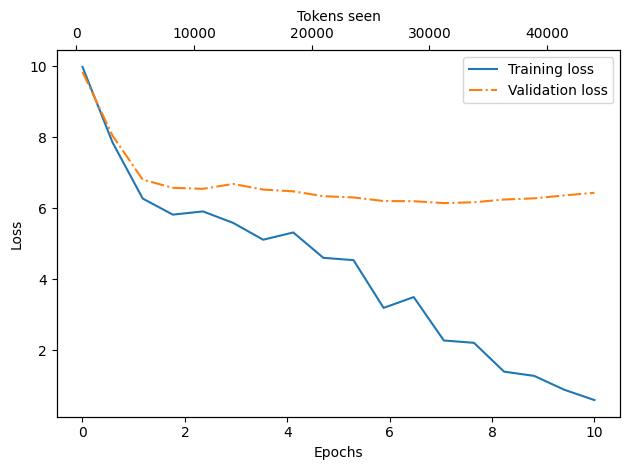

In [6]:

# GPT-2 Small (124M) 모델 설정
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 어휘 크기
    "context_length": 256,  # 훈련 속도를 위해 원본(1024)보다 줄임
    "emb_dim": 768,         # 임베딩 벡터 차원
    "n_heads": 12,          # 어텐션 헤드 개수
    "n_layers": 12,         # 레이어 깊이
    "drop_rate": 0.1,       # 과적합 방지 드롭아웃
    "qkv_bias": False       
}

# 학습 하이퍼파라미터
OTHER_SETTINGS = {
    "learning_rate": 5e-4, 
    "num_epochs": 10,       
    "batch_size": 2,        
    "weight_decay": 0.1     
}

# 하이퍼파라미터: 엔지니어가 미리 세팅하는 값
# 파라미터: 학습 중 스스로 익히는 것. 모델 내부의 가중치, 편향 등

###########################
# 메인 실행: 훈련
###########################
train_losses, val_losses, tokens_seen, model = main(GPT_CONFIG_124M, OTHER_SETTINGS)

###########################
# 훈련 결과 시각화 및 저장
###########################

# 에포크 축 생성 (0부터 num_epochs까지)
# torch.linspace(): linear spacing. 지정된 범위 내에서 일정 간격으로 숫자 생성
epochs_tensor = torch.linspace(0, OTHER_SETTINGS["num_epochs"], len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)
plt.savefig("outputs/loss.pdf")

# 모델 저장 및 로드 테스트
???????

# 디바이스 설정
device = ???????

# 모델 다시 불러오기 테스트
model = ???????

??????? # 2. 가중치 로드

??????? # GPU로 이동

torch.manual_seed(123)
###########################
# 생성 테스트 (Inference)
###########################
tokenizer = ???????

# 훈련된 모델로 텍스트 생성 시도
# Temperature=1.4로 설정하여 다소 창의적/다양한 문장 생성 유도
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))